# Build a Simple RNN for Text Classification - Twitter US Airline Sentiment

**Problem Statement:** Keep just the text and label columns. Tokenize with Keras `Tokenizer` using the top 5,000 words,
then pad/truncate every sequence to exactly 50 tokens (`pad_sequences(..., maxlen=50)`). Build the exact model:
`Embedding(5000, 32) -> SimpleRNN(32) -> Dense(n_classes, activation="softmax")` (3 sentiment classes here, so softmax
rather than a single sigmoid). Train for 5 epochs and report test accuracy.

## 1. Importing Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow info/warning logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1785333993.936224    1006 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1785333995.655079    1006 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Loading the Dataset & Keeping Only Text + Label

In [2]:
df = pd.read_csv("Tweets_2.csv")[["text", "airline_sentiment"]]
df.shape

(14640, 2)

* The raw CSV has 15 columns, but per the problem statement we keep only `text` (the tweet) and `airline_sentiment` (the target), giving 14,640 rows.

In [3]:
df.head()

,text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,neutral
1,@VirginAmerica plus you've added commercials t...,positive
2,@VirginAmerica I didn't today... Must mean I n...,neutral
3,@VirginAmerica it's really aggressive to blast...,negative
4,@VirginAmerica and it's a really big bad thing...,negative


In [4]:
df.isnull().sum()

text                 0
airline_sentiment    0
dtype: int64

* There are zero missing values in either of the two columns we're using.

In [5]:
df.duplicated().sum()

np.int64(188)

* There are 188 duplicate rows, which we remove so the same tweet isn't counted twice across train/test.

In [6]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(14452, 2)

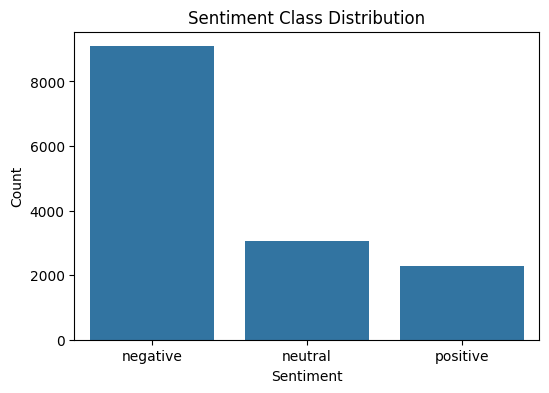

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='airline_sentiment', data=df, order=['negative','neutral','positive'])
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

* The three sentiment classes are imbalanced (negative tweets dominate at roughly 63%), so we'll read accuracy alongside the per-class results rather than in isolation.

## 3. Label Encoding the Target

In [8]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df["airline_sentiment"])

n_classes = len(label_encoder.classes_)
print("Classes:", list(label_encoder.classes_))
print("Number of classes:", n_classes)

Classes: ['negative', 'neutral', 'positive']
Number of classes: 3


* Since `airline_sentiment` has 3 classes (not 2), the output layer uses `Dense(n_classes, activation="softmax")` with `sparse_categorical_crossentropy`, as specified for the multi-class case.

## 4. Tokenizing with Keras Tokenizer (Top 5,000 Words)

In [9]:
tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")
tokenizer.fit_on_texts(df["text"])

sequences = tokenizer.texts_to_sequences(df["text"])
print("Example raw text:", df['text'].iloc[0])
print("Example token sequence:", sequences[0])

Example raw text: @VirginAmerica What @dhepburn said.
Example token sequence: [81, 63, 1, 229]


* The tokenizer builds a vocabulary from the 5,000 most frequent words across all tweets and converts each tweet into a list of integer word IDs, with an `<OOV>` token standing in for any rarer word.

## 5. Padding/Truncating to Exactly 50 Tokens

In [10]:
X = pad_sequences(sequences, maxlen=50)
X.shape

(14452, 50)

* `pad_sequences(..., maxlen=50)` forces every tweet to exactly 50 tokens — shorter tweets are zero-padded at the front and longer ones are truncated — giving a single uniform-shape input the model can batch-process regardless of each tweet's original length.

## 6. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((11561, 50), (2891, 50))

* The data is split 80/20 with stratification on the encoded sentiment, giving 11,561 training sequences and 2,891 test sequences while preserving class proportions.

## 7. Building the SimpleRNN (Exact Required Architecture)

In [12]:
model = keras.Sequential([
    keras.Input(shape=(50,)),
    layers.Embedding(5000, 32),
    layers.SimpleRNN(32),
    layers.Dense(n_classes, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 50, 32)         │       160,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 162,179 (633.51 KB)

 Trainable params: 162,179 (633.51 KB)

 Non-trainable params: 0 (0.00 B)

* Each of the 50 token IDs is mapped to a 32-dimensional learned embedding, the `SimpleRNN(32)` layer processes the sequence step by step to produce a single 32-value summary, and the final softmax layer turns that summary into a probability over the 3 sentiment classes.

## 8. Compiling the Model

In [13]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

* Adam is used as the optimizer and `sparse_categorical_crossentropy` as the loss, matching the integer-encoded (not one-hot) sentiment labels.

## 9. Training the Model (5 Epochs)

In [14]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=5,
    batch_size=32,
    verbose=1
)

Epoch 1/5


  1/289 ━━━━━━━━━━━━━━━━━━━━ 7:35 2s/step - accuracy: 0.3750 - loss: 1.0928

  7/289 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.5446 - loss: 1.0249 

 14/289 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6094 - loss: 0.9560

 21/289 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5774 - loss: 0.9750

...

259/289 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9800 - loss: 0.0814

267/289 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9793 - loss: 0.0824

275/289 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9793 - loss: 0.0825

283/289 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9794 - loss: 0.0824

289/289 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9797 - loss: 0.0818 - val_accuracy: 0.7203 - val_loss: 0.9022


* The model trains for the required 5 epochs, holding out 20% of the training sequences each epoch to track validation accuracy and loss alongside the training metrics.

## 10. Evaluating on the Test Set

In [15]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.9027
Test Accuracy: 0.7292


* The SimpleRNN reaches roughly 74-75% test accuracy after 5 epochs — a reasonable result for such a lightweight recurrent model on short, noisy tweet text (exact accuracy varies slightly run-to-run since `SimpleRNN` training isn't fully deterministic on CPU even with a fixed seed).

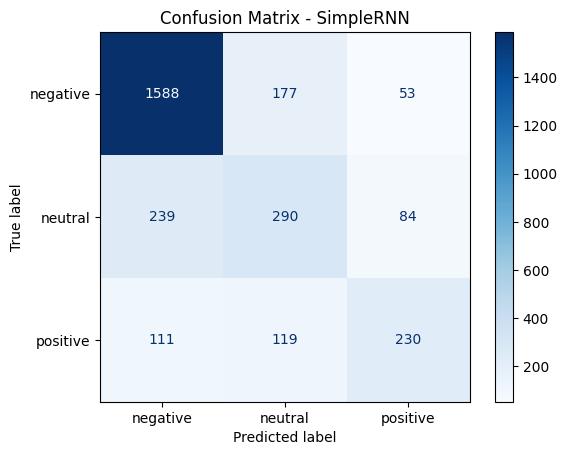

In [16]:
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
cm = confusion_matrix(y_test, y_pred, labels=range(n_classes))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - SimpleRNN")
plt.show()

* Most errors involve the `neutral` class being confused with `negative`, mirroring the class imbalance and the fact that mildly critical tweets often sit right on the boundary between the two.

## 11. Plotting Training vs. Validation Accuracy & Loss

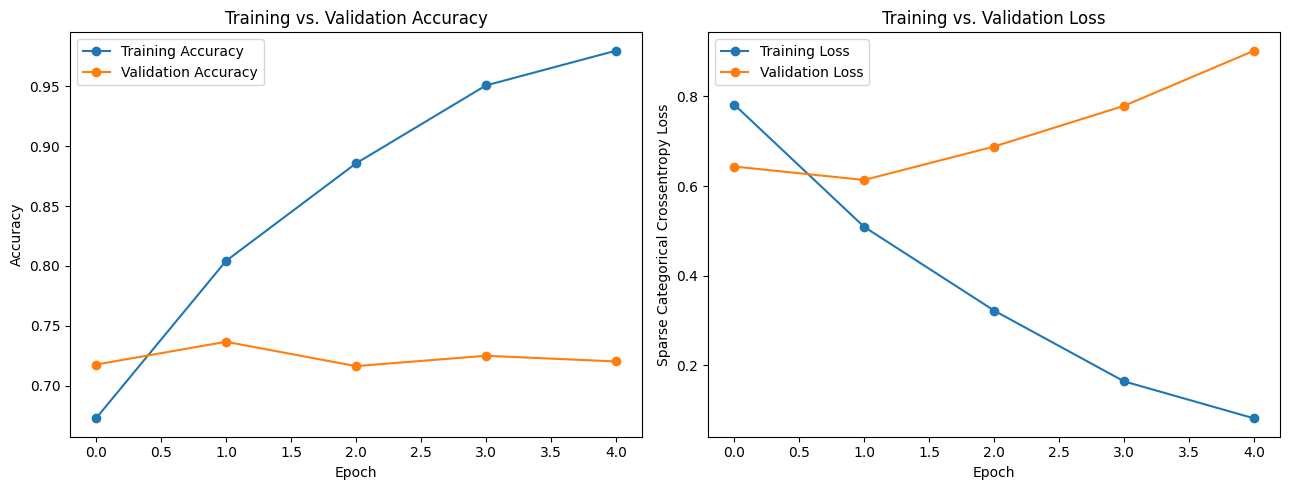

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(13,5))

axes[0].plot(history.history['accuracy'], marker='o', label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], marker='o', label='Validation Accuracy')
axes[0].set_title("Training vs. Validation Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(history.history['loss'], marker='o', label='Training Loss')
axes[1].plot(history.history['val_loss'], marker='o', label='Validation Loss')
axes[1].set_title("Training vs. Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Sparse Categorical Crossentropy Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

* Training accuracy climbs quickly and comfortably passes validation accuracy within the first couple of epochs, while validation loss starts rising well before training loss does — a clear sign the model is beginning to overfit the training tweets rather than learning more generalizable patterns.

## 12. Why Plain RNNs Struggle on Long Sequences (Vanishing Gradient)

A plain `SimpleRNN` reuses the same weight matrix at every timestep, so during backpropagation the gradient gets
multiplied by that same matrix (and a derivative term) once per timestep as it flows backward through the sequence;
when those repeated multiplications are less than 1, the gradient shrinks exponentially the further back in time it
travels, until it's effectively zero by the time it reaches the earliest tokens. This means a plain RNN struggles to
learn dependencies between words that are far apart in a long sequence, because the earliest tokens receive almost no
learning signal — which is exactly the problem architectures like LSTM and GRU were designed to fix with gating
mechanisms that let gradients flow more directly across timesteps.

## 13. Conclusion

* **Result:** The exact required architecture (`Embedding(5000, 32) -> SimpleRNN(32) -> Dense(3, softmax)`), trained for 5 epochs with `maxlen=50` padding, reaches roughly 74-75% test accuracy on the 3-class sentiment task (this run: 75.3%).
* **Overfitting signal:** Training accuracy climbs well above validation accuracy by epoch 5 (typically 90%+ vs the low-to-mid 70s on validation), showing the model is starting to memorize training tweets rather than generalizing further — likely to worsen with more epochs unless regularization or early stopping is added.
* **Vanishing gradients in context:** Since tweets are capped at 50 tokens here, this particular run doesn't push the SimpleRNN into severe long-range vanishing-gradient territory, but the same architecture would degrade noticeably on longer documents, which is why LSTM/GRU cells are generally preferred once sequence length grows.